<a href="https://colab.research.google.com/github/basilhakim/FYP-SMART-HYDROPONIC-WITH-EDGE-AI/blob/main/yololettucedetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the Ultralytics library
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.0/112.6 GB disk)


In [ ]:
# Unzip the uploaded dataset
!unzip -q nutrient\ defficiencyyolov11.zip -d /content/dataset

# List the files to verify it unzipped correctly
!ls /content/dataset

replace /content/dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
data.yaml  README.roboflow.txt	test  train  valid


In [ ]:
from ultralytics import YOLO

# Load the YOLOv8 Small model
model = YOLO('yolov8s.pt')

# Train the model
# Adjust 'data' path to point directly to your data.yaml file inside the unzipped folder
# 'epochs=50' is a good starting point. Increase to 100 if the model is still learning.
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    project='plant_health',
    name='yolov8_training'
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [ ]:
# Validate the model's accuracy
metrics = model.val()

print(f"Mean Average Precision @ 50 (mAP50): {metrics.box.map50:.3f}")
print(f"Mean Average Precision @ 50-95 (mAP50-95): {metrics.box.map:.3f}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1409.1±661.0 MB/s, size: 77.6 KB)
val: Scanning /content/dataset/valid/labels.cache... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 38.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 89, len(boxes) = 91. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.1it/s 2.8s
                   all         91         91       0.64      0.743      0.695      0.671
                     K         19         19      0.693      0.632      0.658      0.615
                     N         13         13     

--- TRAINING LOSS CURVE ---


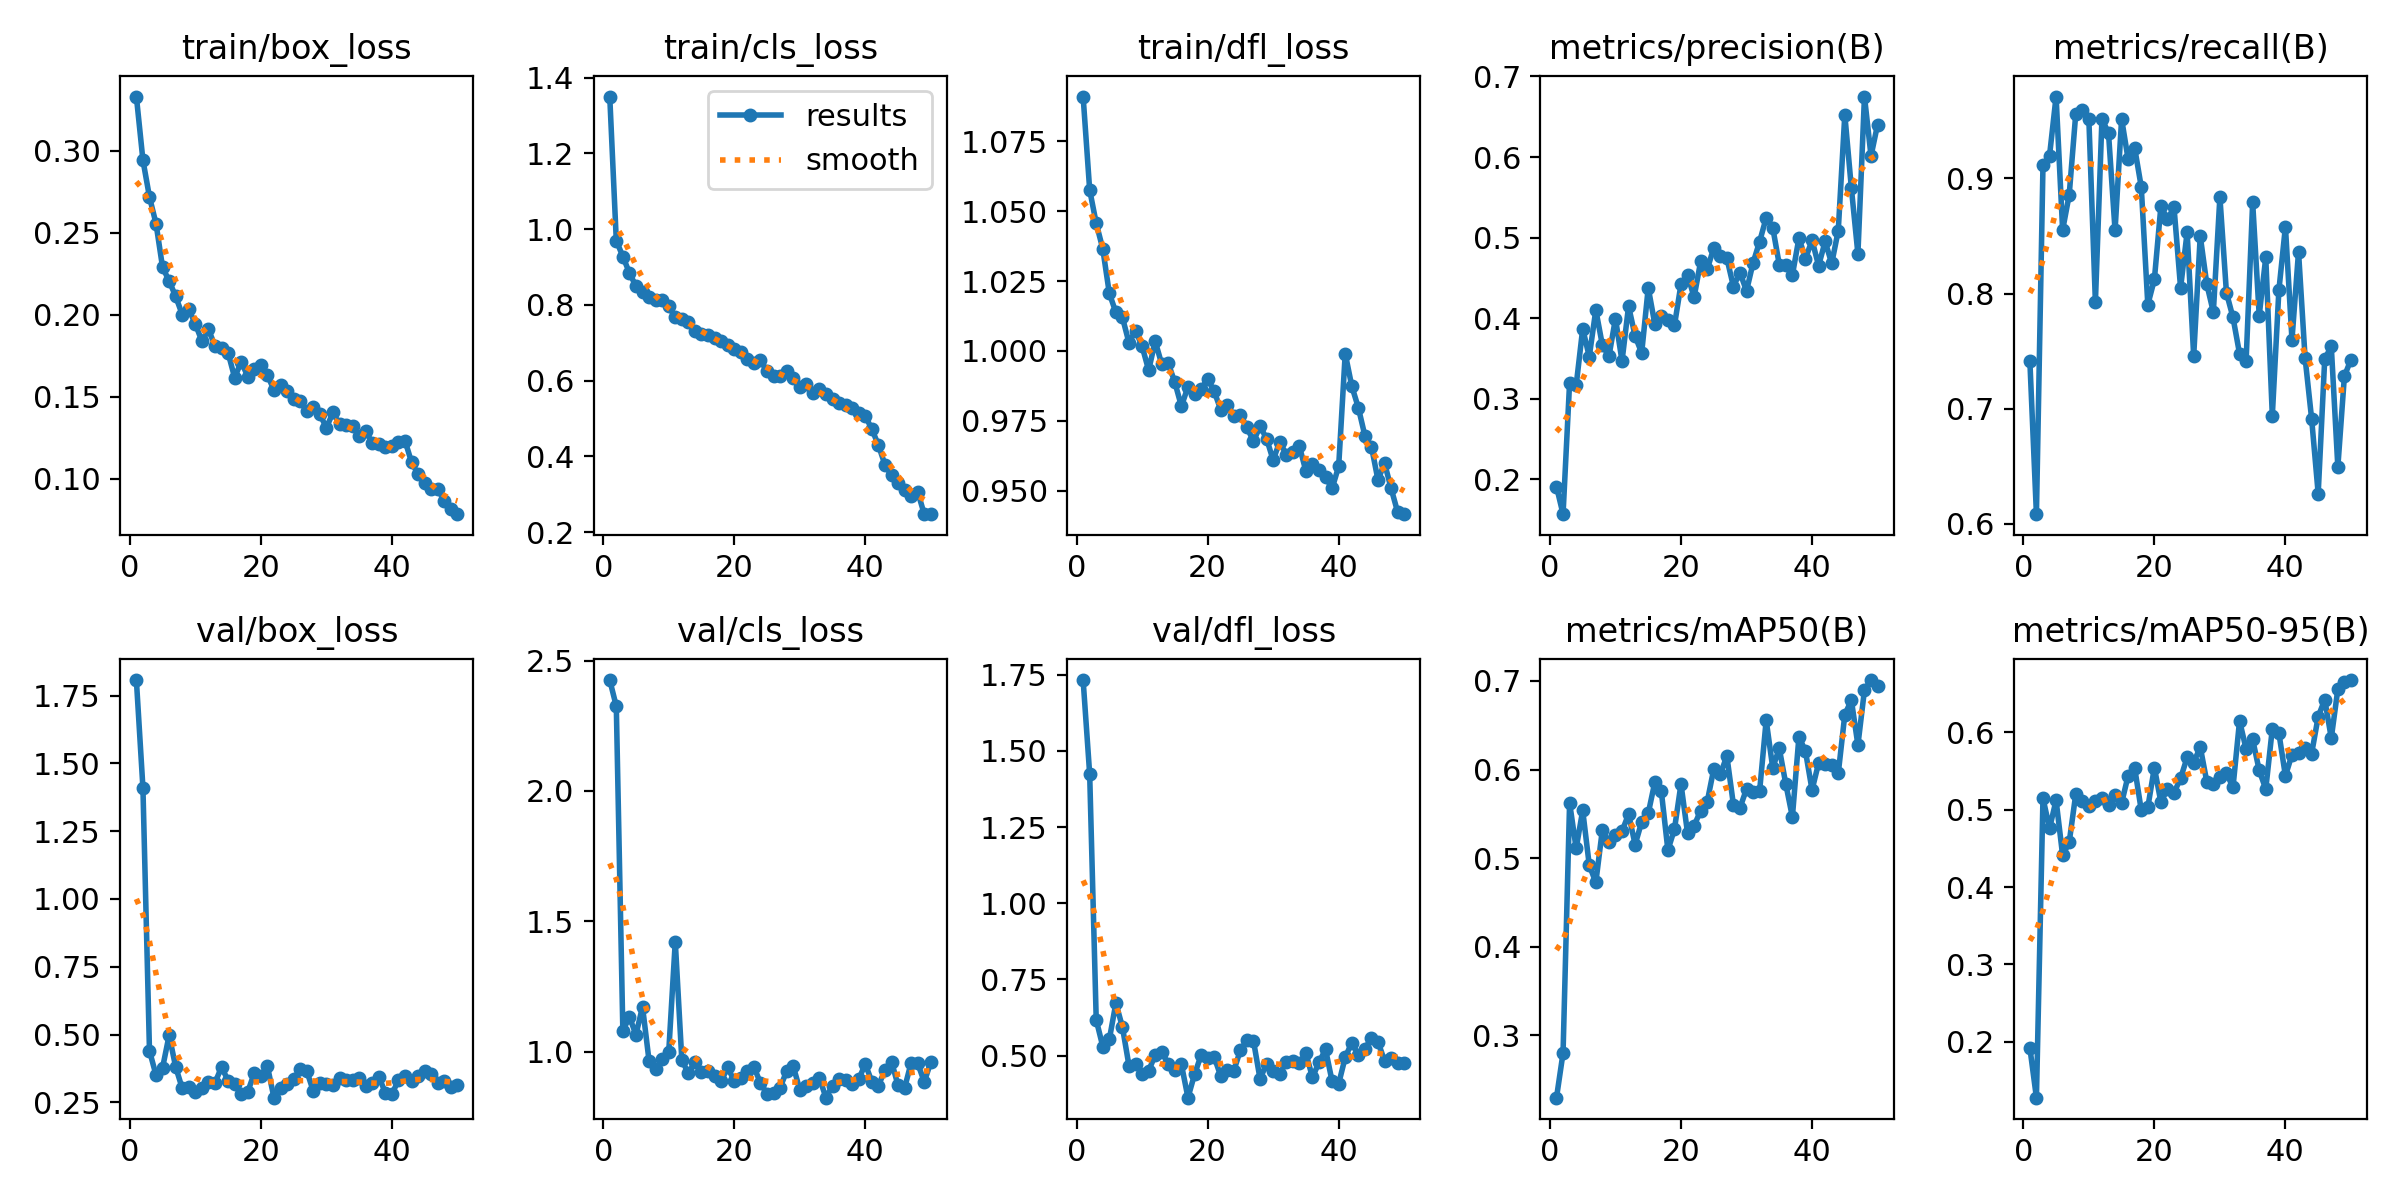


--- CONFUSION MATRIX ---


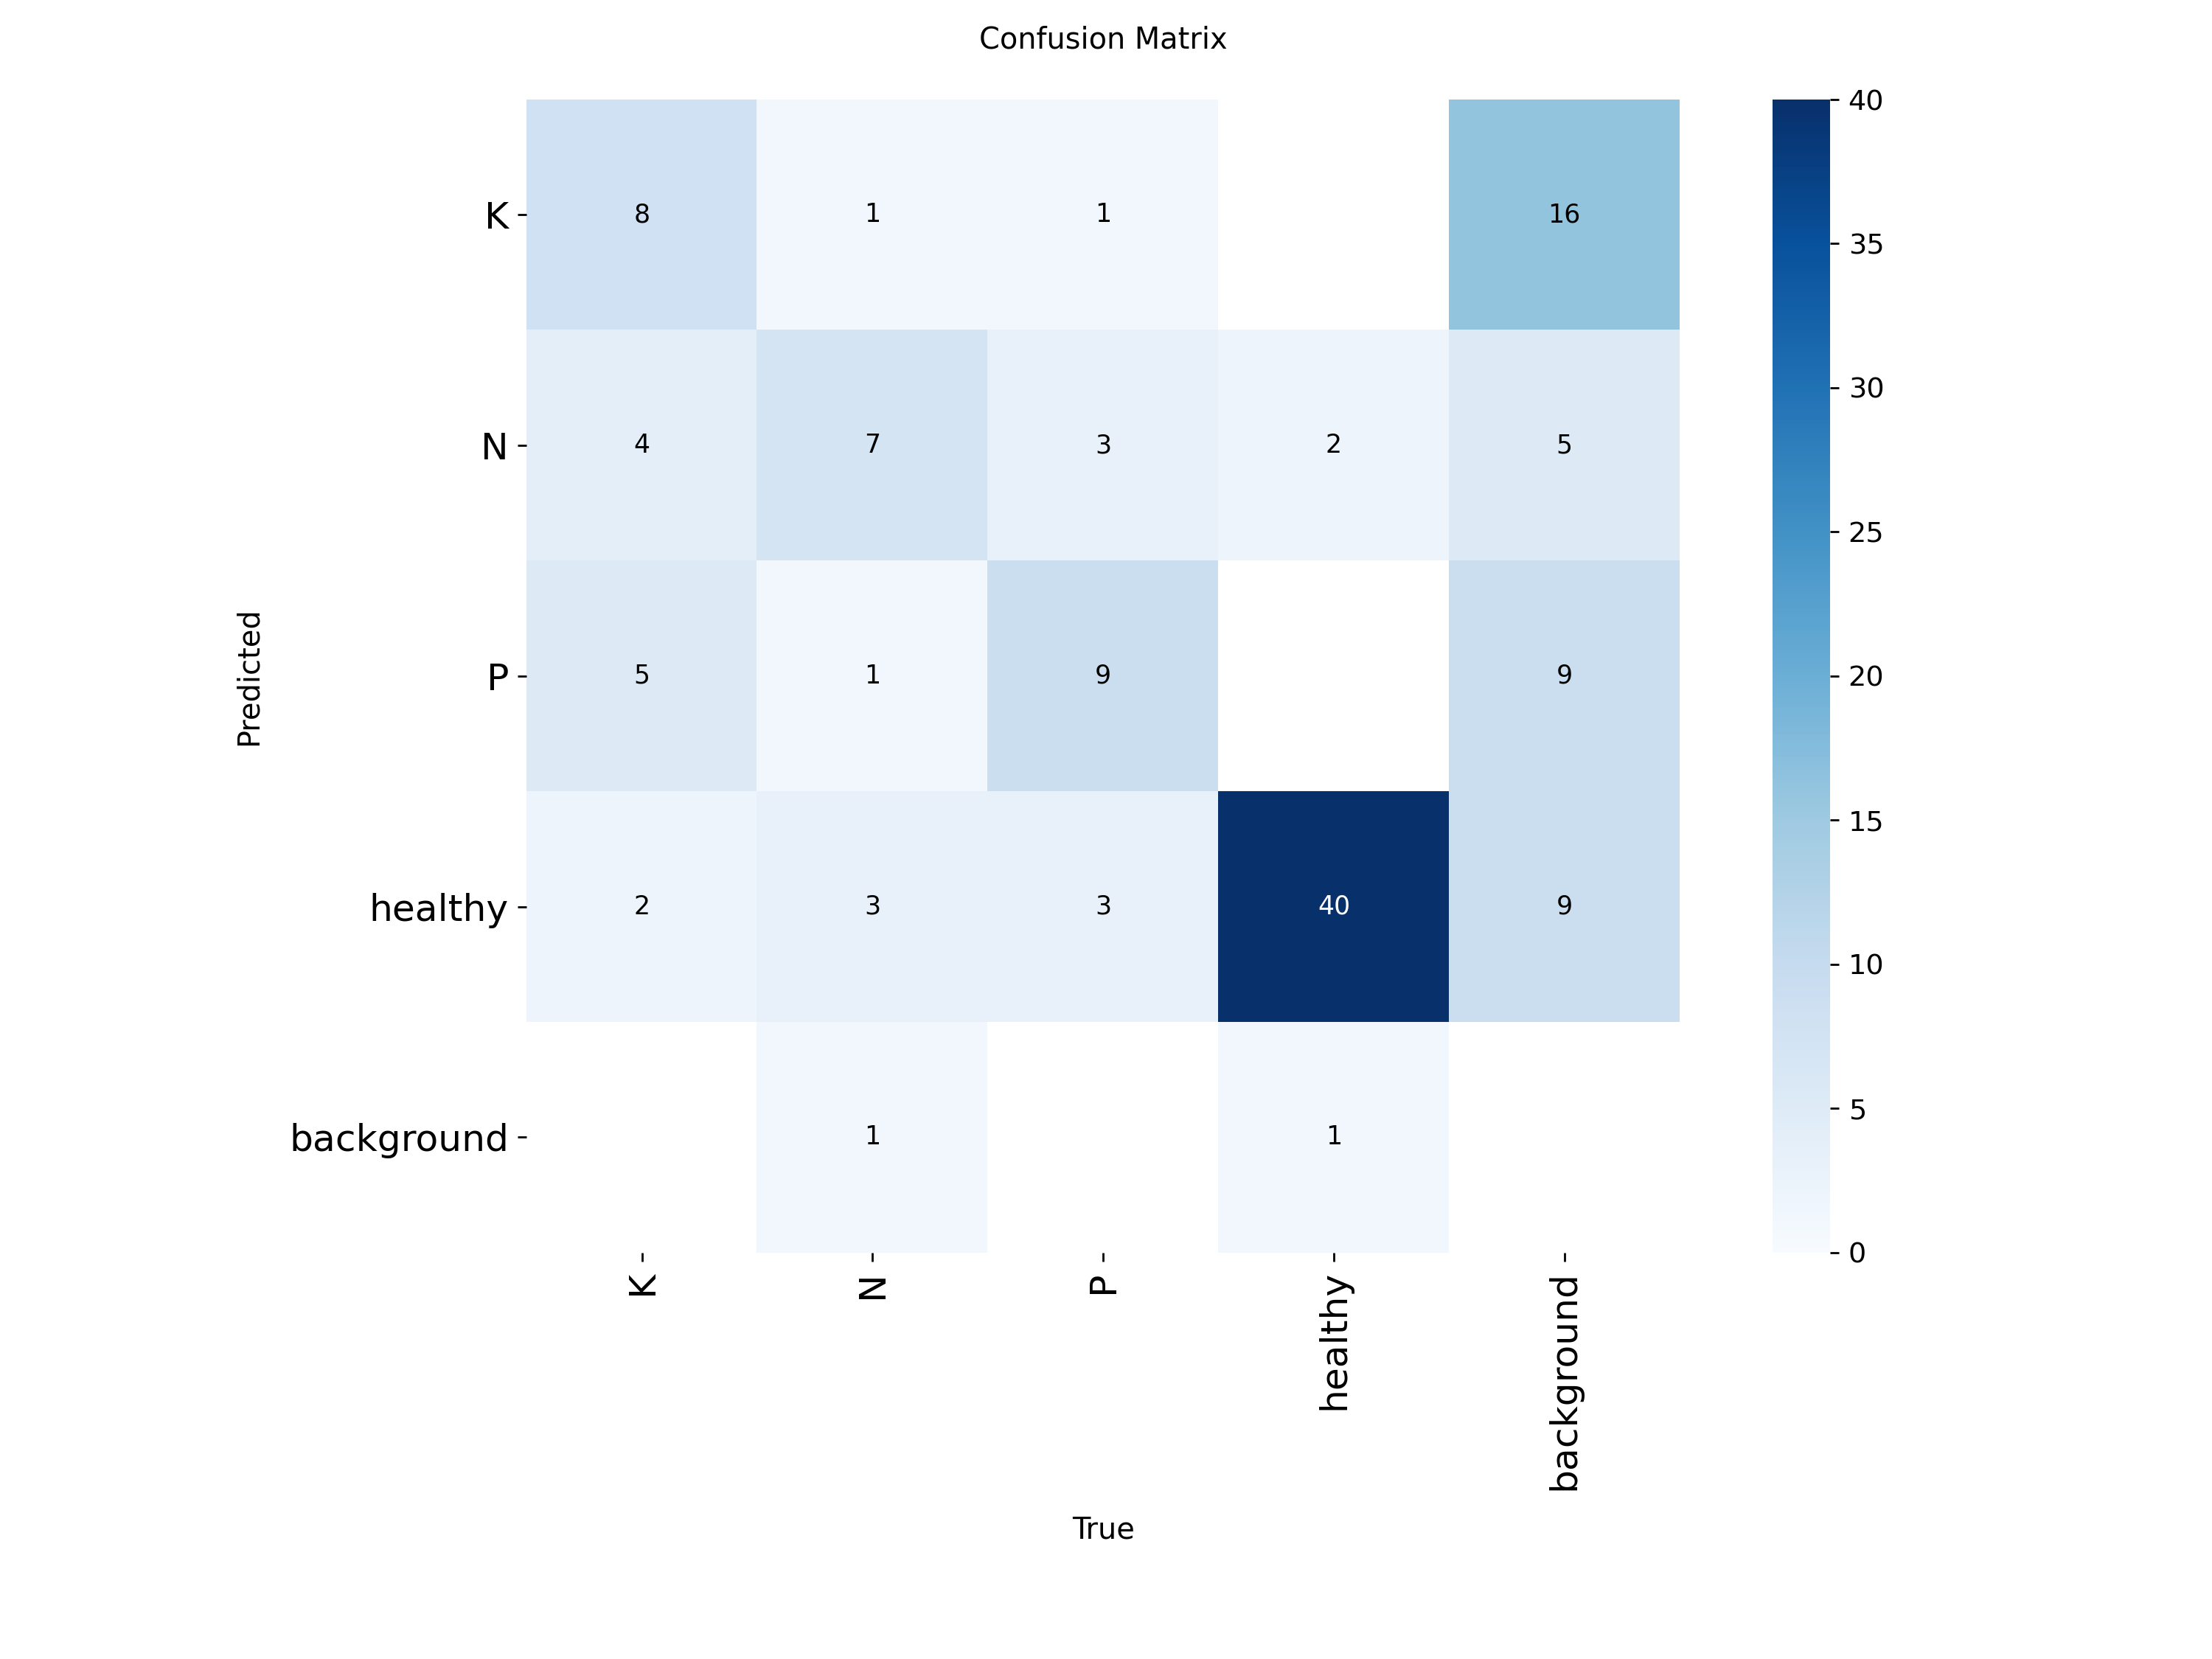


--- PRECISION-RECALL CURVE ---


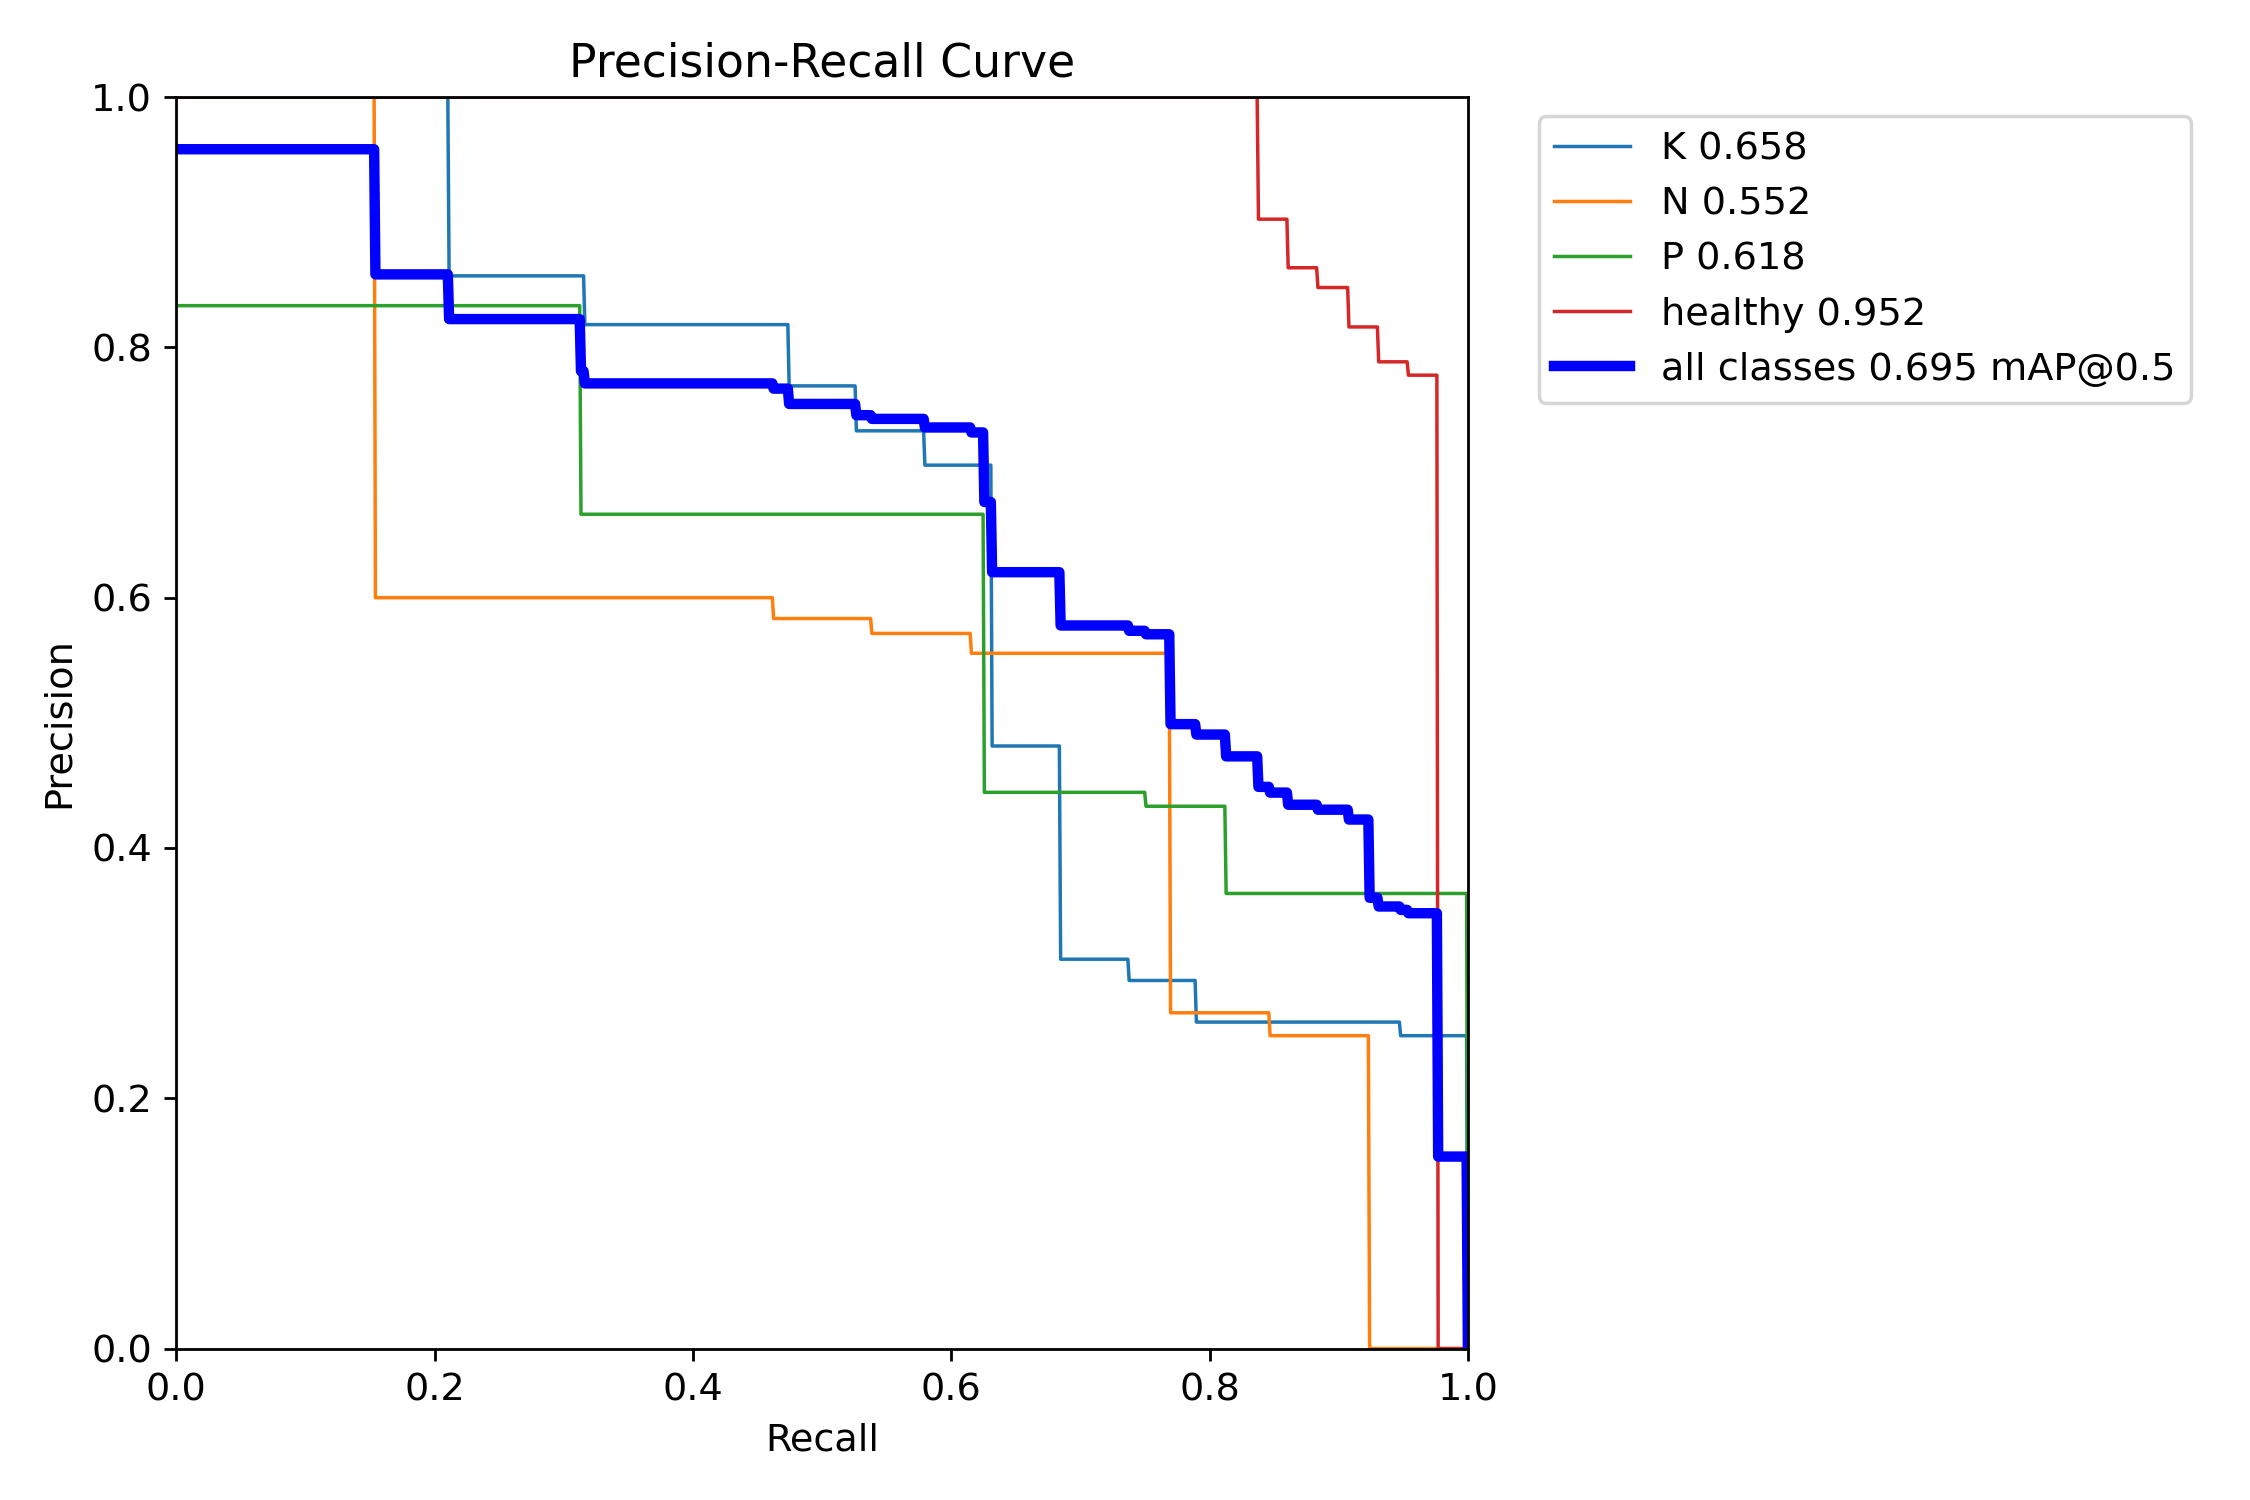

In [ ]:
from IPython.display import Image, display
import os

# Define the path where YOLO saved the training results (for training specific plots)
training_results_dir = '/content/runs/detect/plant_health/yolov8_training/'

# Define the path where YOLO saved the validation results (for validation specific plots)
val_results_dir = '/content/runs/detect/val/'

print("--- TRAINING LOSS CURVE ---")
display(Image(filename=os.path.join(training_results_dir, 'results.png'), width=800))

print("\n--- CONFUSION MATRIX ---")
display(Image(filename=os.path.join(training_results_dir, 'confusion_matrix.png'), width=600))

print("\n--- PRECISION-RECALL CURVE ---")
display(Image(filename=os.path.join(val_results_dir, 'BoxPR_curve.png'), width=600))

### Evaluating Model Performance from Plots

We have three key plots to assess the performance of our YOLOv8 object detection model:

1.  **Training Loss Curve (`results.png`)**:
    *   This plot shows the different loss components over the training epochs. A good training run will typically show all loss curves decreasing steadily.
    *   **`box_loss`**: Represents the loss associated with the bounding box regression (how well the model predicts the object's location and size). Lower is better.
    *   **`cls_loss`**: Represents the classification loss (how well the model predicts the correct class of the object). Lower is better.
    *   **`dfl_loss`**: (Distribution Focal Loss) A more advanced loss for bounding box localization, focusing on the distribution of distances. Lower is better.
    *   **Interpretation**: If the losses are consistently decreasing, it means the model is learning. If they plateau or start increasing, it might indicate overfitting or that the learning rate is too high.

2.  **Confusion Matrix (`confusion_matrix.png`)**:
    *   The confusion matrix is a table used to describe the performance of a classification model on a set of test data for which the true values are known.
    *   **Rows**: Represent the actual classes.
    *   **Columns**: Represent the predicted classes.
    *   **Diagonal values**: Show the number of correct predictions for each class (True Positives).
    *   **Off-diagonal values**: Show misclassifications (False Positives and False Negatives).
    *   **Interpretation**: Ideally, you want high values on the diagonal and low values elsewhere. This indicates that the model is accurately classifying objects. High off-diagonal values show specific classes that the model is confusing with each other.

3.  **Precision-Recall Curve (`BoxPR_curve.png`)**:
    *   This curve illustrates the trade-off between **Precision** and **Recall** for different thresholds.
    *   **Precision**: The proportion of positive identifications that were actually correct (True Positives / (True Positives + False Positives)). High precision means fewer false alarms.
    *   **Recall (Sensitivity)**: The proportion of actual positives that were correctly identified (True Positives / (True Positives + False Negatives)). High recall means fewer missed detections.
    *   **Interpretation**: A good model will have a curve that stays close to the top-right corner. The area under this curve is the **Average Precision (AP)** for that class. The **mean Average Precision (mAP)**, which we printed earlier, is the average AP across all classes and is a primary metric for object detection performance.

In [ ]:
print(f"Contents of {val_results_dir}:")
!ls -R {val_results_dir}

Contents of /content/runs/detect/val/:
/content/runs/detect/val/:
BoxF1_curve.png  confusion_matrix_normalized.png  val_batch1_labels.jpg
BoxP_curve.png	 confusion_matrix.png		  val_batch1_pred.jpg
BoxPR_curve.png  val_batch0_labels.jpg		  val_batch2_labels.jpg
BoxR_curve.png	 val_batch0_pred.jpg		  val_batch2_pred.jpg


### "best.pt" file will be used for deployment:

In [ ]:
from google.colab import files

# Download the best weights to your local machine
best_model_path = '/content/runs/detect/plant_health/yolov8_training/weights/best.pt'
files.download(best_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Download Training Results and Validation Plots

To download all the generated plots and logs from the training and validation runs, we'll zip the respective directories and then use `files.download`.

In [ ]:
# Zip the training results directory
!zip -r /content/training_results.zip {training_results_dir}

# Download the zipped training results
from google.colab import files
files.download('/content/training_results.zip')

  adding: content/runs/detect/plant_health/yolov8_training/ (stored 0%)
  adding: content/runs/detect/plant_health/yolov8_training/train_batch8562.jpg (deflated 7%)
  adding: content/runs/detect/plant_health/yolov8_training/args.yaml (deflated 53%)
  adding: content/runs/detect/plant_health/yolov8_training/val_batch0_labels.jpg (deflated 7%)
  adding: content/runs/detect/plant_health/yolov8_training/results.png (deflated 7%)
  adding: content/runs/detect/plant_health/yolov8_training/weights/ (stored 0%)
  adding: content/runs/detect/plant_health/yolov8_training/weights/best.pt (deflated 8%)
  adding: content/runs/detect/plant_health/yolov8_training/weights/last.pt (deflated 8%)
  adding: content/runs/detect/plant_health/yolov8_training/BoxP_curve.png (deflated 8%)
  adding: content/runs/detect/plant_health/yolov8_training/BoxR_curve.png (deflated 11%)
  adding: content/runs/detect/plant_health/yolov8_training/val_batch2_pred.jpg (deflated 6%)
  adding: content/runs/detect/plant_health/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Zip the validation results directory
!zip -r /content/validation_plots.zip {val_results_dir}

# Download the zipped validation results
from google.colab import files
files.download('/content/validation_plots.zip')

  adding: content/runs/detect/val/ (stored 0%)
  adding: content/runs/detect/val/val_batch0_labels.jpg (deflated 7%)
  adding: content/runs/detect/val/BoxP_curve.png (deflated 8%)
  adding: content/runs/detect/val/BoxR_curve.png (deflated 11%)
  adding: content/runs/detect/val/val_batch2_pred.jpg (deflated 5%)
  adding: content/runs/detect/val/BoxPR_curve.png (deflated 17%)
  adding: content/runs/detect/val/confusion_matrix.png (deflated 32%)
  adding: content/runs/detect/val/val_batch2_labels.jpg (deflated 6%)
  adding: content/runs/detect/val/val_batch1_labels.jpg (deflated 7%)
  adding: content/runs/detect/val/confusion_matrix_normalized.png (deflated 24%)
  adding: content/runs/detect/val/BoxF1_curve.png (deflated 9%)
  adding: content/runs/detect/val/val_batch1_pred.jpg (deflated 6%)
  adding: content/runs/detect/val/val_batch0_pred.jpg (deflated 6%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>